In [3]:
!pip install numpy

In [4]:
import numpy as np 
import pandas as pd
import pickle
from pathlib import Path

In [5]:
with open("routerbench/routerbench_raw.pkl", "rb") as f:
        raw_obj = pickle.load(f)

C:\Users\prana\AppData\Local\Temp\ipykernel_22936\3402734920.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  raw_obj = pickle.load(f)


In [6]:
df = raw_obj if isinstance(raw_obj, pd.DataFrame) else pd.DataFrame(raw_obj)
initial_count = len(df)
print(f"Loaded {initial_count} raw records.")

Loaded 401467 raw records.


In [7]:
df.drop(columns=['sample_id', 'index'], inplace=True)

In [8]:
df.head()

,prompt,eval_name,performance,model_response,model_name,cost
0,"[""Imagine you are participating in a race with...",mtbench-math,0.1,"['If I have just overtaken the second person, ...",gpt-3.5-turbo-1106,0.000194
1,['You can see a beautiful red house to your le...,mtbench-math,1.0,['The White House is located in Washington D.C...,gpt-3.5-turbo-1106,0.000134
2,"['The vertices of a triangle are at points (0,...",mtbench-math,0.2,"['To find the area of the triangle, we can use...",gpt-3.5-turbo-1106,0.001197
3,"[""A tech startup invests $8000 in software dev...",mtbench-math,1.0,"['In the first year, the startup invested $800...",gpt-3.5-turbo-1106,0.000300
4,"[""In a survey conducted at a local high school...",mtbench-math,0.1,['To find the probability that a student would...,gpt-3.5-turbo-1106,0.000761


In [9]:
df['eval_name'].value_counts()

eval_name
hellaswag                    110462
grade-school-math             81950
mmlu-professional-law         16874
arc-challenge                 16170
winogrande                    13937
                              ...  
chinese-remainder-theorem       165
chinese_chu_ci                  165
chinese_poem                    165
chinese_idioms                  165
test-match                       33
Name: count, Length: 86, dtype: int64

In [10]:
df['model_name'].value_counts()

model_name
gpt-3.5-turbo-1106                   36497
claude-instant-v1                    36497
claude-v1                            36497
claude-v2                            36497
gpt-4-1106-preview                   36497
meta/llama-2-70b-chat                36497
mistralai/mixtral-8x7b-chat          36497
zero-one-ai/Yi-34B-Chat              36497
WizardLM/WizardLM-13B-V1.2           36497
meta/code-llama-instruct-34b-chat    36497
mistralai/mistral-7b-chat            36497
Name: count, dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401467 entries, 0 to 276335
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   prompt          401467 non-null  object 
 1   eval_name       401467 non-null  object 
 2   performance     401467 non-null  object 
 3   model_response  401467 non-null  object 
 4   model_name      401467 non-null  object 
 5   cost            401467 non-null  float64
dtypes: float64(1), object(5)
memory usage: 21.4+ MB


In [12]:
print("Unique Benchmarks (eval_name):")
print(df["eval_name"].value_counts())

print("\nUnique Models (model_name):")
print(df["model_name"].value_counts())

print(f"\nUnique Prompts: {df['prompt'].nunique():,}")

Unique Benchmarks (eval_name):
eval_name
hellaswag                    110462
grade-school-math             81950
mmlu-professional-law         16874
arc-challenge                 16170
winogrande                    13937
                              ...  
chinese-remainder-theorem       165
chinese_chu_ci                  165
chinese_poem                    165
chinese_idioms                  165
test-match                       33
Name: count, Length: 86, dtype: int64

Unique Models (model_name):
model_name
gpt-3.5-turbo-1106                   36497
claude-instant-v1                    36497
claude-v1                            36497
claude-v2                            36497
gpt-4-1106-preview                   36497
meta/llama-2-70b-chat                36497
mistralai/mixtral-8x7b-chat          36497
zero-one-ai/Yi-34B-Chat              36497
WizardLM/WizardLM-13B-V1.2           36497
meta/code-llama-instruct-34b-chat    36497
mistralai/mistral-7b-chat            36497
Name: count,

In [13]:
MODEL_NAME_MAP = {
    "mistralai/mistral-7b-chat": "mistral_7b",
    "mistralai/mixtral-8x7b-chat": "mixtral_8x7b",
    "meta/llama-2-70b-chat": "llama_2_70b",
    "meta/code-llama-instruct-34b-chat": "code_llama_34b",
    "zero-one-ai/Yi-34B-Chat": "yi_34b",
    "WizardLM/WizardLM-13B-V1.2": "wizardlm_13b",
    "gpt-3.5-turbo-1106": "gpt_35_turbo",
    "gpt-4-1106-preview": "gpt_4",
    "claude-instant-v1": "claude_instant",
    "claude-v1": "claude_v1",
    "claude-v2": "claude_v2"
}

df["clean_model"] = df["model_name"].map(MODEL_NAME_MAP)

In [14]:
df.head()

,prompt,eval_name,performance,model_response,model_name,cost,clean_model
0,"[""Imagine you are participating in a race with...",mtbench-math,0.1,"['If I have just overtaken the second person, ...",gpt-3.5-turbo-1106,0.000194,gpt_35_turbo
1,['You can see a beautiful red house to your le...,mtbench-math,1.0,['The White House is located in Washington D.C...,gpt-3.5-turbo-1106,0.000134,gpt_35_turbo
2,"['The vertices of a triangle are at points (0,...",mtbench-math,0.2,"['To find the area of the triangle, we can use...",gpt-3.5-turbo-1106,0.001197,gpt_35_turbo
3,"[""A tech startup invests $8000 in software dev...",mtbench-math,1.0,"['In the first year, the startup invested $800...",gpt-3.5-turbo-1106,0.000300,gpt_35_turbo
4,"[""In a survey conducted at a local high school...",mtbench-math,0.1,['To find the probability that a student would...,gpt-3.5-turbo-1106,0.000761,gpt_35_turbo


In [15]:
import ast

df = df.reset_index(drop=True)


def clean_text_field(val):
    """Strips enclosing brackets, quotes, and unwraps list representations."""
    if isinstance(val, (list, tuple, np.ndarray)):
        return "\n".join(str(item).strip() for item in val).strip()

    if isinstance(val, str):
        s = val.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple)):
                    return "\n".join(str(item).strip() for item in parsed).strip()
            except Exception:
                inner = s[1:-1].strip()
                if (inner.startswith("'") and inner.endswith("'")) or (
                    inner.startswith('"') and inner.endswith('"')
                ):
                    inner = inner[1:-1].strip()
                return inner
        return s

    return str(val).strip()

print("Cleaning 'prompt' and 'model_response'...")
df["prompt"] = df["prompt"].apply(clean_text_field)
df["model_response"] = df["model_response"].apply(clean_text_field)

print("Converting 'performance' to float32...")
df["performance"] = (
    pd.to_numeric(df["performance"], errors="coerce")
    .fillna(0.0)
    .astype("float32")
)

df["cost"] = df["cost"].astype("float32")

print("Cleaning complete.")

Cleaning 'prompt' and 'model_response'...
Converting 'performance' to float32...
Cleaning complete.


In [16]:
df["model_name"] = df["model_name"].astype("category")
df["clean_model"] = df["clean_model"].astype("category")
df["eval_name"] = df["eval_name"].astype("category")

try:
    df["prompt"] = df["prompt"].astype("string[pyarrow]")
    df["model_response"] = df["model_response"].astype("string[pyarrow]")
    print("Applied PyArrow-backed string dtypes.")
except Exception:
    df["prompt"] = df["prompt"].astype("string")
    df["model_response"] = df["model_response"].astype("string")
    print("Applied standard Pandas string dtypes.")

df["performance"] = df["performance"].astype("float32")
df["cost"] = df["cost"].astype("float32")

df.info()

Applied PyArrow-backed string dtypes.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401467 entries, 0 to 401466
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   prompt          401467 non-null  string  
 1   eval_name       401467 non-null  category
 2   performance     401467 non-null  float32 
 3   model_response  401467 non-null  string  
 4   model_name      401467 non-null  category
 5   cost            401467 non-null  float32 
 6   clean_model     401467 non-null  category
dtypes: category(3), float32(2), string(2)
memory usage: 1.1 GB


In [17]:
!pip install -q tiktoken

In [18]:
df.head()

,prompt,eval_name,performance,model_response,model_name,cost,clean_model
0,Imagine you are participating in a race with a...,mtbench-math,0.1,"If I have just overtaken the second person, my...",gpt-3.5-turbo-1106,0.000194,gpt_35_turbo
1,You can see a beautiful red house to your left...,mtbench-math,1.0,"The White House is located in Washington D.C.,...",gpt-3.5-turbo-1106,0.000134,gpt_35_turbo
2,"The vertices of a triangle are at points (0, 0...",mtbench-math,0.2,"To find the area of the triangle, we can use t...",gpt-3.5-turbo-1106,0.001197,gpt_35_turbo
3,A tech startup invests $8000 in software devel...,mtbench-math,1.0,"In the first year, the startup invested $8000 ...",gpt-3.5-turbo-1106,0.000300,gpt_35_turbo
4,"In a survey conducted at a local high school, ...",mtbench-math,0.1,To find the probability that a student would l...,gpt-3.5-turbo-1106,0.000761,gpt_35_turbo


In [19]:
import tiktoken

encoder = tiktoken.get_encoding('cl100k_base')

In [20]:
df["output_tokens"] = df["model_response"].apply(
    lambda text: float(max(1, len(encoder.encode(str(text), disallowed_special=()))))
).astype("float32")

df["prompt_tokens"] = df["prompt"].apply(
    lambda text: float(max(1, len(encoder.encode(str(text), disallowed_special=()))))
).astype("float32")

df.head()

,prompt,eval_name,performance,model_response,model_name,cost,clean_model,output_tokens,prompt_tokens
0,Imagine you are participating in a race with a...,mtbench-math,0.1,"If I have just overtaken the second person, my...",gpt-3.5-turbo-1106,0.000194,gpt_35_turbo,66.0,62.0
1,You can see a beautiful red house to your left...,mtbench-math,1.0,"The White House is located in Washington D.C.,...",gpt-3.5-turbo-1106,0.000134,gpt_35_turbo,40.0,54.0
2,"The vertices of a triangle are at points (0, 0...",mtbench-math,0.2,"To find the area of the triangle, we can use t...",gpt-3.5-turbo-1106,0.001197,gpt_35_turbo,575.0,47.0
3,A tech startup invests $8000 in software devel...,mtbench-math,1.0,"In the first year, the startup invested $8000 ...",gpt-3.5-turbo-1106,0.000300,gpt_35_turbo,109.0,82.0
4,"In a survey conducted at a local high school, ...",mtbench-math,0.1,To find the probability that a student would l...,gpt-3.5-turbo-1106,0.000761,gpt_35_turbo,338.0,87.0


In [21]:
df['clean_model'].value_counts()

clean_model
claude_instant    36497
claude_v1         36497
claude_v2         36497
code_llama_34b    36497
gpt_35_turbo      36497
gpt_4             36497
llama_2_70b       36497
mistral_7b        36497
mixtral_8x7b      36497
wizardlm_13b      36497
yi_34b            36497
Name: count, dtype: int64

In [24]:
import os
import csv
import pandas as pd

OUTPUT_DIR = "data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CSV_PATH = f"{OUTPUT_DIR}/clean_router_data.csv"

# 1. Check and drop duplicate (prompt, eval_name, clean_model) entries
dup_count = df.duplicated(subset=["prompt", "eval_name", "clean_model"]).sum()
print(f"Found {dup_count} duplicate key entries. Deduplicating...")

# Keep the first occurrence of each model's run for that prompt
df_dedup = df.drop_duplicates(subset=["prompt", "eval_name", "clean_model"], keep="first").copy()

# 2. Pivot using pivot_table with aggfunc='first' (safe against collisions)
print("Pivoting performance scores and token counts to wide format...")
pivot_scores = df_dedup.pivot_table(
    index=["prompt", "eval_name"],
    columns="clean_model",
    values="performance",
    aggfunc="first"
)

pivot_tokens = df_dedup.pivot_table(
    index=["prompt", "eval_name"],
    columns="clean_model",
    values="output_tokens",
    aggfunc="first"
)

# 3. Rename columns to avoid collisions
pivot_scores.columns = [f"{col}_score" for col in pivot_scores.columns]
pivot_tokens.columns = [f"{col}_tokens" for col in pivot_tokens.columns]

# 4. Merge into a single wide DataFrame
df_export = pd.concat([pivot_scores, pivot_tokens], axis=1).reset_index()

# 5. Attach prompt_tokens
prompt_tokens_map = df_dedup.groupby("prompt")["prompt_tokens"].first()
df_export["prompt_tokens"] = df_export["prompt"].map(prompt_tokens_map)

# 6. Add deterministic query ID
df_export.insert(0, "query_id", [f"rb_{i:06d}" for i in range(len(df_export))])

print(f"Pivoting successful! Wide shape: {df_export.shape}")

# 7. Export to CSV
print(f"Exporting to {CSV_PATH}...")
df_export.to_csv(
    CSV_PATH,
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_MINIMAL
)

file_size_mb = os.path.getsize(CSV_PATH) / (1024 * 1024)
print(f"Done! Clean dataset exported ({len(df_export):,} rows, {file_size_mb:.2f} MB).")

Found 154 duplicate key entries. Deduplicating...
Pivoting performance scores and token counts to wide format...


C:\Users\prana\AppData\Local\Temp\ipykernel_22936\744679336.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_scores = df_dedup.pivot_table(
C:\Users\prana\AppData\Local\Temp\ipykernel_22936\744679336.py:25: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_tokens = df_dedup.pivot_table(


Pivoting successful! Wide shape: (36497, 26)
Exporting to data/processed/clean_router_data.csv...
Done! Clean dataset exported (36,497 rows, 99.38 MB).


In [25]:
df.head()

,prompt,eval_name,performance,model_response,model_name,cost,clean_model,output_tokens,prompt_tokens
0,Imagine you are participating in a race with a...,mtbench-math,0.1,"If I have just overtaken the second person, my...",gpt-3.5-turbo-1106,0.000194,gpt_35_turbo,66.0,62.0
1,You can see a beautiful red house to your left...,mtbench-math,1.0,"The White House is located in Washington D.C.,...",gpt-3.5-turbo-1106,0.000134,gpt_35_turbo,40.0,54.0
2,"The vertices of a triangle are at points (0, 0...",mtbench-math,0.2,"To find the area of the triangle, we can use t...",gpt-3.5-turbo-1106,0.001197,gpt_35_turbo,575.0,47.0
3,A tech startup invests $8000 in software devel...,mtbench-math,1.0,"In the first year, the startup invested $8000 ...",gpt-3.5-turbo-1106,0.000300,gpt_35_turbo,109.0,82.0
4,"In a survey conducted at a local high school, ...",mtbench-math,0.1,To find the probability that a student would l...,gpt-3.5-turbo-1106,0.000761,gpt_35_turbo,338.0,87.0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401467 entries, 0 to 401466
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   prompt          401467 non-null  string  
 1   eval_name       401467 non-null  category
 2   performance     401467 non-null  float32 
 3   model_response  401467 non-null  string  
 4   model_name      401467 non-null  category
 5   cost            401467 non-null  float32 
 6   clean_model     401467 non-null  category
 7   output_tokens   401467 non-null  float32 
 8   prompt_tokens   401467 non-null  float32 
dtypes: category(3), float32(4), string(2)
memory usage: 1.1 GB


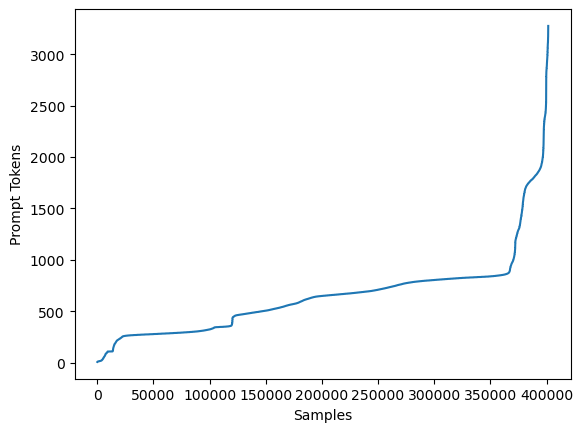

In [32]:
import matplotlib.pyplot as plt 

plt.plot(df['prompt_tokens'].sort_values().reset_index(drop=True))
plt.xlabel("Samples")
plt.ylabel("Prompt Tokens")
plt.show()

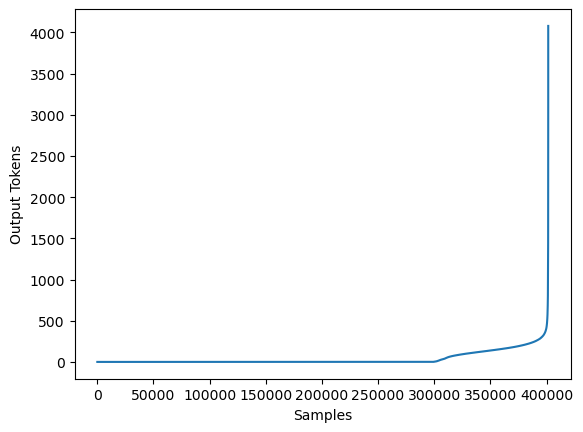

In [33]:
import matplotlib.pyplot as plt 

plt.plot(df['output_tokens'].sort_values().reset_index(drop=True))
plt.xlabel("Samples")
plt.ylabel("Output Tokens")
plt.show()

In [27]:
df.describe()

,performance,cost,output_tokens,prompt_tokens
count,401467.000000,401467.000000,401467.000000,401467.000000
mean,0.614163,0.002277,40.157677,650.518738
std,0.441574,0.003244,90.659515,411.441040
min,0.000000,0.000004,1.000000,8.000000
25%,0.000000,0.000340,1.000000,325.000000
50%,0.750000,0.000698,1.000000,650.000000
75%,1.000000,0.003792,6.000000,806.000000
max,1.000000,0.050730,4079.000000,3275.000000
